In [105]:
## Imports from 1_clean_merge_data.ipynb
import pandas as pd
import numpy as np
import re
import requests
import yaml
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import curve_fit
import time

## Set font parameters early
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

headers = {
    'User-Agent': 'EskildsenLogan research project (logan.j.eskildsen.28@dartmouth.edu)'
}

## Repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [142]:
## Load relevant wikipedia data for visualization
culture_final_df = pd.read_csv('../data/culture_final_data.csv')
football_final_df = pd.read_csv('../data/football_final_data.csv')
country_final_df = pd.read_csv('../data/country_final_data.csv')

## Load relevant search trend data for visualization
regional_final_df = pd.read_csv('../data/regional_final_data.csv')

In [143]:
## The Wikipedia data I seek to plot is the ratio above mean baseline over time. For the country and football datasets, this is easy.

football_final_df['ratio_to_baseline'] = football_final_df['views'] / football_final_df['mean_views']
## Dates corrupted
football_final_df['date'] = pd.to_datetime(football_final_df['date'].astype(str).str.extract(r'(\d{8}$)')[0], format='%Y%m%d')

football_final_df[['country', 'article_title', 'date', 'views', 'mean_views', 'ratio_to_baseline']]

country_final_df['ratio_to_baseline'] = country_final_df['views'] / country_final_df['mean_views']

country_final_df['date'] = pd.to_datetime(country_final_df['date'].astype(str).str.extract(r'(\d{8}$)')[0], format='%Y%m%d')

country_final_df[['country', 'article_title', 'date', 'views', 'mean_views', 'ratio_to_baseline']]

## For the culture dataset, create a new DataFrame that sums the views of all articles over one day and compare to baseline.

culture_final_plot_df = culture_final_df.groupby(['country', 'date'])[['views', 'mean_views']].sum().reset_index().rename(columns={'views': 'total_views', 'mean_views': 'total_mean_views'})
culture_final_plot_df['ratio_to_baseline'] = culture_final_plot_df['total_views'] / culture_final_plot_df['total_mean_views']


culture_final_plot_df['date'] = pd.to_datetime(culture_final_plot_df['date'].astype(str).str.extract(r'(\d{8}$)')[0], format='%Y%m%d')

culture_final_plot_df

,country,article_title,date,views,mean_views,ratio_to_baseline
0,Australia,Australia National Football Team,2026-05-27,22,29.7,0.740741
1,Australia,Australia National Football Team,2026-05-28,30,29.7,1.010101
2,Australia,Australia National Football Team,2026-05-29,29,29.7,0.976431
3,Australia,Australia National Football Team,2026-05-30,134,29.7,4.511785
4,Australia,Australia National Football Team,2026-05-31,31,29.7,1.043771
...,...,...,...,...,...,...
425,Turkey,Turkey National Football Team,2026-08-16,1498,2691.9,0.556484
426,Turkey,Turkey National Football Team,2026-08-17,1497,2691.9,0.556113
427,Turkey,Turkey National Football Team,2026-08-18,1526,2691.9,0.566886
428,Turkey,Turkey National Football Team,2026-08-19,1440,2691.9,0.534938


,country,article_title,date,views,mean_views,ratio_to_baseline
0,Australia,Australia,2026-05-27,13894,14697.3,0.945344
1,Australia,Australia,2026-05-28,14621,14697.3,0.994809
2,Australia,Australia,2026-05-29,14654,14697.3,0.997054
3,Australia,Australia,2026-05-30,12149,14697.3,0.826614
4,Australia,Australia,2026-05-31,12996,14697.3,0.884244
...,...,...,...,...,...,...
425,Turkey,Turkey,2026-08-16,10865,11430.3,0.950544
426,Turkey,Turkey,2026-08-17,11153,11430.3,0.975740
427,Turkey,Turkey,2026-08-18,10818,11430.3,0.946432
428,Turkey,Turkey,2026-08-19,10596,11430.3,0.927010


,country,date,total_views,total_mean_views,ratio_to_baseline
0,Australia,2026-05-27,28059,28509.125000,0.984211
1,Australia,2026-05-28,32084,28509.125000,1.125394
2,Australia,2026-05-29,33580,28505.236111,1.178029
3,Australia,2026-05-30,27653,28509.125000,0.969970
4,Australia,2026-05-31,29618,28500.025000,1.039227
...,...,...,...,...,...
425,Turkey,2026-08-16,7873,8138.511111,0.967376
426,Turkey,2026-08-17,7538,8150.761111,0.924822
427,Turkey,2026-08-18,7389,8150.761111,0.906541
428,Turkey,2026-08-19,7185,8133.761111,0.883355


Australia 2026-06-19 00:00:00 2026-05-27 00:00:00 2026-08-20 00:00:00


Text(0.5, 1.0, 'Australia')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Ratio to Baseline Views')

(1.0, 2.3725446170385043)

...

Text(0.5, 1.0, 'Turkey')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Ratio to Baseline Views')

(1.0, 5.422674820433411)

Text(0.5, 1.02, 'Wikipedia Country Engagement by Searched Country')

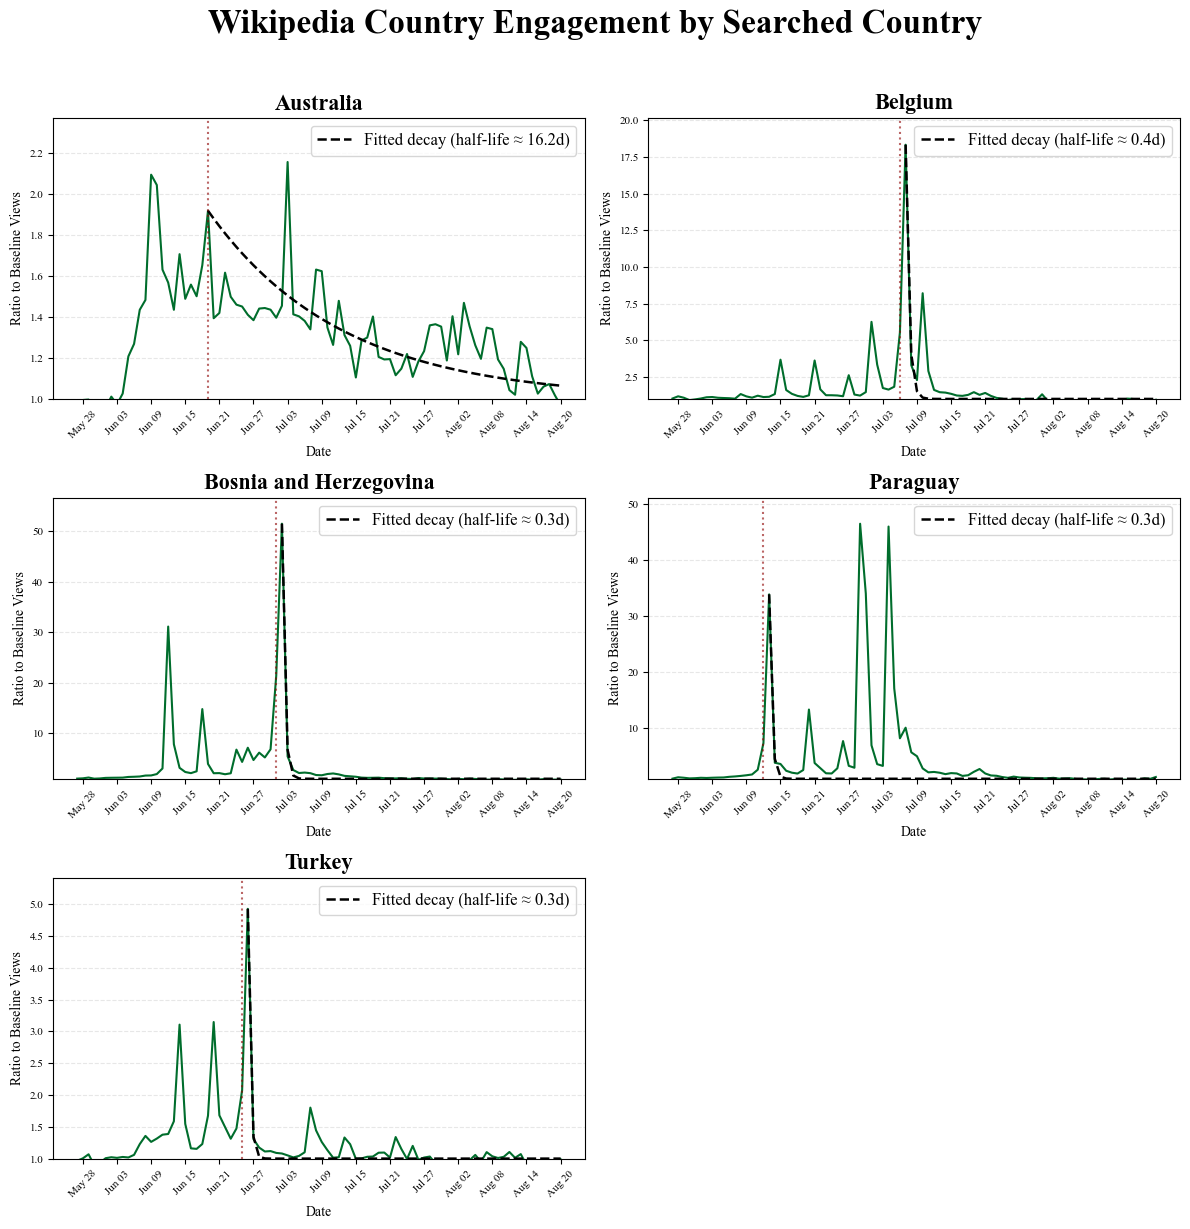

In [177]:
## I would define a function but I want to tune the parameters for each dataset individually

## This is the country decay curve

## Now plot timeseries with fitted decay

match_dates = {
    'Australia': pd.Timestamp('2026-06-19'),
    'Belgium': pd.Timestamp('2026-07-06'),
    'Bosnia_and_Herzegovina': pd.Timestamp('2026-07-01'),
    'Paraguay': pd.Timestamp('2026-06-12'),
    'Turkey': pd.Timestamp('2026-06-25'),
}

countries = list(match_dates.keys())

## Ensure date column is real datetime, once, up front
country_final_df['date'] = pd.to_datetime(country_final_df['date'])

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

A = None

def decay_func(t, lam):
    return (A - 1) * np.exp(-lam * t) + 1

fit_results = []
    
for ax, country in zip(axes, countries):
    match_date = match_dates[country]
    
    test_d = country_final_df[country_final_df['country'] == country].sort_values('date').copy()
    print(country, match_date, test_d['date'].min(), test_d['date'].max())
    if test_d.empty:
        ax.set_title(f"{country} (no data)", fontsize=12)
        continue

    ## Now define a window that tests if there is a nearby maximum from the match date

    
    ## Isolate data from the match date onward, for THIS country only
    post_match = test_d[test_d['date'] >= match_date].copy()
    post_match['days_since_match'] = (post_match['date'] - match_date).dt.days

    if post_match.empty:
        ax.set_title(f"{country} (no post-match data)", fontsize=12)
        continue
    
    peak_window = post_match[(post_match['days_since_match'] >= 0) & (post_match['days_since_match'] <= 2)]

    if not peak_window.empty:
        peak_row = peak_window.loc[peak_window['ratio_to_baseline'].idxmax()]
        A = peak_row['ratio_to_baseline']
        peak_ratio_date = peak_row['days_since_match']
    else:
        A = post_match['ratio_to_baseline'].iloc[0]
        peak_ratio_date = 0
#& (post_match['days_since_match'] <= 30)].
    fitted_window = post_match[post_match['days_since_match'] >= peak_ratio_date].copy()
    fitted_window['t_since_peak'] = fitted_window['days_since_match'] - peak_ratio_date

    try:
        p0 = [0.2]
        params, pcov = curve_fit(decay_func, fitted_window['t_since_peak'], fitted_window['ratio_to_baseline'],
                              p0=p0, sigma=fitted_window['ratio_to_baseline'], maxfev=10000)
        lam_fit = params[0]
        fitted_curve = decay_func(fitted_window['t_since_peak'], lam_fit)
        half_life = np.log(2) / lam_fit

        se_lam = np.sqrt(np.diag(pcov))[0]
        se_half_life = se_lam * np.log(2) / (lam_fit ** 2)
        ss_res = np.sum((fitted_window['ratio_to_baseline'] - fitted_curve) ** 2)
        ss_tot = np.sum((fitted_window['ratio_to_baseline'] - fitted_window['ratio_to_baseline'].mean()) ** 2)
        r_squared = 1 - ss_res / ss_tot

        fit_label = f'Fitted decay (half-life ≈ {half_life:.1f}d)'
        fit_success = True

        fit_results.append({
        'country': country, 'peak_ratio': A, 'peak_day_since_match': peak_ratio_date,
        'lambda': lam_fit, 'lambda_se': se_lam,
        'half_life_days': half_life, 'half_life_se': se_half_life,
        'r_squared': r_squared, 'n_points_fit': len(fitted_window)
        })
    except Exception as e:
        print(f"Curve fit failed for {country}: {e}")
        fit_success = False
        fit_results.append({
        'country': country, 'peak_ratio': A, 'peak_day_since_match': peak_ratio_date,
        'lambda': np.nan, 'lambda_se': np.nan, 'half_life_days': np.nan,
        'half_life_se': np.nan, 'r_squared': np.nan, 'n_points_fit': len(fitted_window)
        })
    
    ## Plot raw data for THIS country only
    ax.plot(test_d['date'], test_d['ratio_to_baseline'], color='#006D2C', linewidth=1.5)
    
    if fit_success:
        ax.plot(fitted_window['date'], fitted_curve, color='#000000', linewidth=1.8,
                linestyle='--', label=fit_label)
        ax.legend(fontsize=12)
    
    ax.set_title(country.replace('_', ' '), fontsize=16, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=6))
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_xlabel("Date", fontsize=10)
    ax.set_ylabel("Ratio to Baseline Views", fontsize=10)
    ## y-axis scaled to THIS country's own max, not the global max
    ax.set_ylim(1, max(test_d['ratio_to_baseline']) * 1.1)
    
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.axvline(match_date, color='#8e0000', linestyle=':', alpha=0.6)

for i in range(5, len(axes)):
    fig.delaxes(axes[i])

fig.suptitle("Wikipedia Country Engagement by Searched Country", fontsize=24, fontweight='bold', y=1.02)

plt.tight_layout()
fig.savefig('../outputs/figure_1.png', dpi=300, bbox_inches='tight')
plt.show()

In [147]:
pd.DataFrame(fit_results)

,country,peak_ratio,peak_day_since_match,lambda,lambda_se,half_life_days,half_life_se,r_squared,n_points_fit
0,Australia,1.918924,0,0.042755,0.003319,16.212123,1.258618,0.155526,63
1,Belgium,18.329505,1,1.747388,0.234797,0.396676,0.053302,0.832559,45
2,Bosnia_and_Herzegovina,51.540987,1,2.179978,0.217769,0.317961,0.031763,0.995271,50
3,Paraguay,33.829670,1,2.227174,0.550559,0.311223,0.076934,0.010537,69
4,Turkey,4.929704,1,2.442502,0.439441,0.283786,0.051057,0.907625,56


Text(0.5, 0, 'Date')

Text(0, 0.5, 'Ratio to Baseline Views')

Text(0.5, 1.0, 'Australia')

(1.0, 15.407407407407408)

Text(0.5, 0, 'Date')

...

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Ratio to Baseline Views')

Text(0.5, 1.0, 'Turkey')

(1.0, 26.32660945800364)

Text(0.5, 1.02, 'Wikipedia Football Engagement by Searched Country')

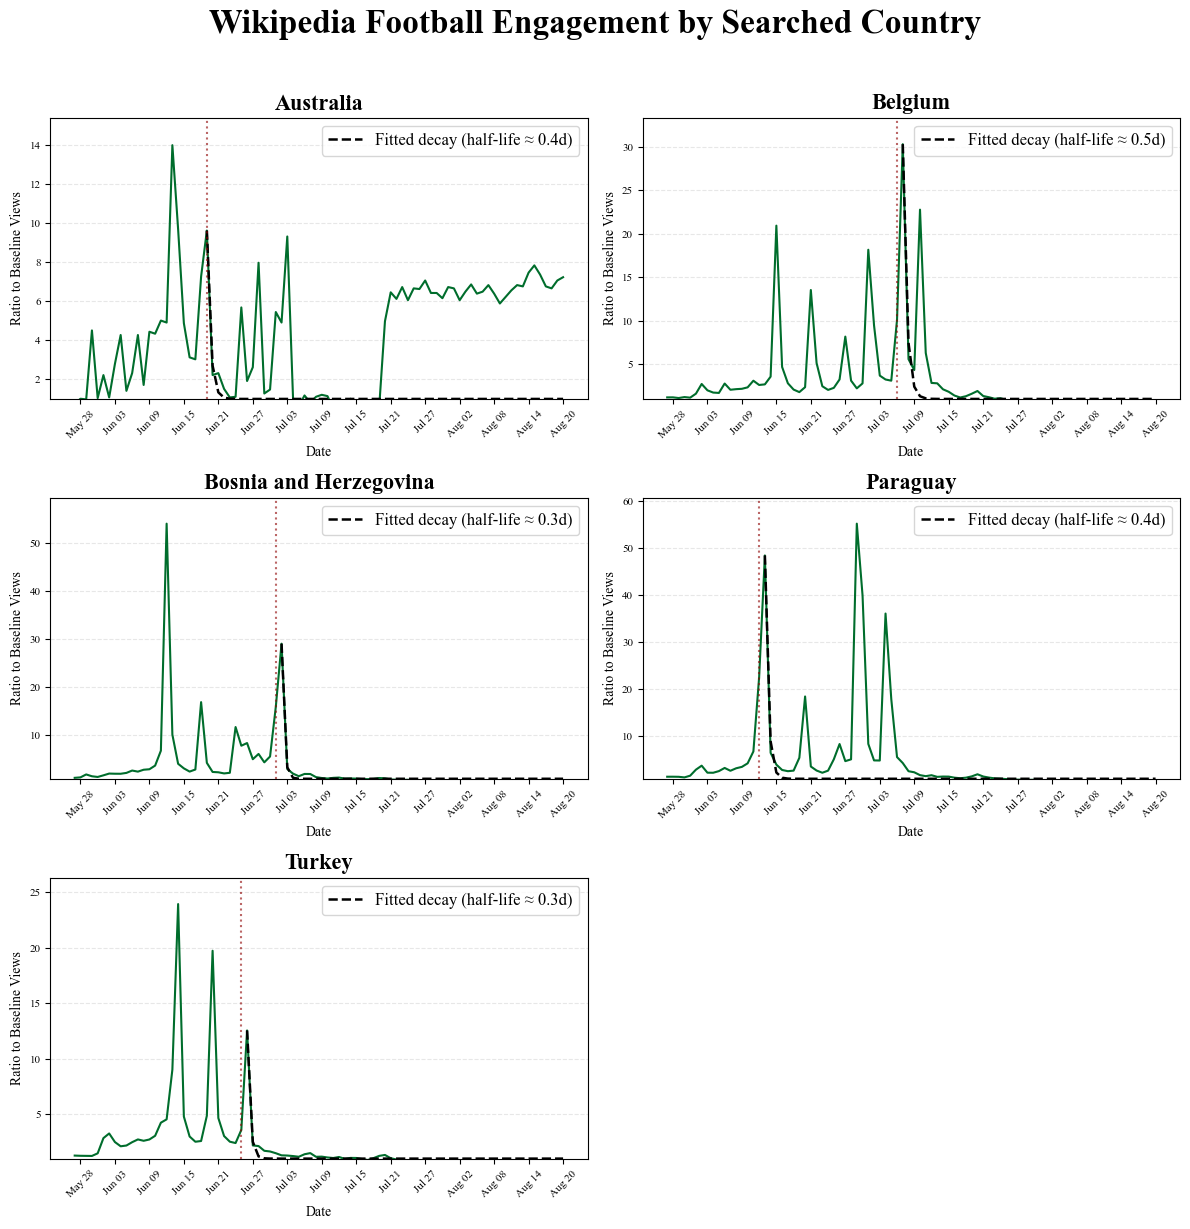

In [176]:
## I would define a function but I want to tune the parameters for each dataset individually

## This is the country decay curve

## Now plot timeseries with fitted decay

match_dates = {
    'Australia': pd.Timestamp('2026-06-19'),
    'Belgium': pd.Timestamp('2026-07-06'),
    'Bosnia_and_Herzegovina': pd.Timestamp('2026-07-01'),
    'Paraguay': pd.Timestamp('2026-06-12'),
    'Turkey': pd.Timestamp('2026-06-25'),
}

countries = list(match_dates.keys())

## Ensure date column is real datetime, once, up front
football_final_df['date'] = pd.to_datetime(football_final_df['date'])

fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=False, sharey=False)
axes = axes.flatten()

A = None

def decay_func(t, lam):
    return (A - 1) * np.exp(-lam * t) + 1

fit_results = []
    
for ax, country in zip(axes, countries):
    match_date = match_dates[country]
    
    test_d = football_final_df[football_final_df['country'] == country].sort_values('date').copy()
    ## Now define a window that tests if there is a nearby maximum from the match date

    
    ## Isolate data from the match date onward, for THIS country only
    post_match = test_d[test_d['date'] >= match_date].copy()
    post_match['days_since_match'] = (post_match['date'] - match_date).dt.days

    
    peak_window = post_match[(post_match['days_since_match'] >= 0) & (post_match['days_since_match'] <= 2)]

    if not peak_window.empty:
        peak_row = peak_window.loc[peak_window['ratio_to_baseline'].idxmax()]
        A = peak_row['ratio_to_baseline']
        peak_ratio_date = peak_row['days_since_match']
    else:
        A = post_match['ratio_to_baseline'].iloc[0]
        peak_ratio_date = 0
#& (post_match['days_since_match'] <= 30)].
    fitted_window = post_match[post_match['days_since_match'] >= peak_ratio_date].copy()
    fitted_window['t_since_peak'] = fitted_window['days_since_match'] - peak_ratio_date

    try:
        p0 = [0.2]
        params, pcov = curve_fit(decay_func, fitted_window['t_since_peak'], fitted_window['ratio_to_baseline'],
                              p0=p0, sigma=fitted_window['ratio_to_baseline'], maxfev=10000)
        lam_fit = params[0]
        fitted_curve = decay_func(fitted_window['t_since_peak'], lam_fit)
        half_life = np.log(2) / lam_fit

        se_lam = np.sqrt(np.diag(pcov))[0]
        se_half_life = se_lam * np.log(2) / (lam_fit ** 2)
        ss_res = np.sum((fitted_window['ratio_to_baseline'] - fitted_curve) ** 2)
        ss_tot = np.sum((fitted_window['ratio_to_baseline'] - fitted_window['ratio_to_baseline'].mean()) ** 2)
        r_squared = 1 - ss_res / ss_tot

        fit_label = f'Fitted decay (half-life ≈ {half_life:.1f}d)'
        fit_success = True

        fit_results.append({
        'country': country, 'peak_ratio': A, 'peak_day_since_match': peak_ratio_date,
        'lambda': lam_fit, 'lambda_se': se_lam,
        'half_life_days': half_life, 'half_life_se': se_half_life,
        'r_squared': r_squared, 'n_points_fit': len(fitted_window)
        })
    except Exception as e:
        print(f"Curve fit failed for {country}: {e}")
        fit_success = False
        fit_results.append({
        'country': country, 'peak_ratio': A, 'peak_day_since_match': peak_ratio_date,
        'lambda': np.nan, 'lambda_se': np.nan, 'half_life_days': np.nan,
        'half_life_se': np.nan, 'r_squared': np.nan, 'n_points_fit': len(fitted_window)
        })
    
    ## Plot raw data for THIS country only
    ax.plot(test_d['date'], test_d['ratio_to_baseline'], color='#006D2C', linewidth=1.5)

    ax.set_xlabel("Date", fontsize=10)
    ax.set_ylabel("Ratio to Baseline Views", fontsize=10)
    
    
    if fit_success:
        ax.plot(fitted_window['date'], fitted_curve, color='#000000', linewidth=1.8,
                linestyle='--', label=fit_label)
        ax.legend(fontsize=12)
    
    ax.set_title(country.replace('_', ' '), fontsize=16, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=6))
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    
    ## y-axis scaled to THIS country's own max, not the global max
    ax.set_ylim(1, max(test_d['ratio_to_baseline']) * 1.1)
    
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.axvline(match_date, color='#8e0000', linestyle=':', alpha=0.6)

for i in range(5, len(axes)):
    fig.delaxes(axes[i])

fig.suptitle("Wikipedia Football Engagement by Searched Country", fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig('../outputs/figure_2.png', dpi=300, bbox_inches='tight')
plt.show()

In [153]:
pd.DataFrame(fit_results)

,country,peak_ratio,peak_day_since_match,lambda,lambda_se,half_life_days,half_life_se,r_squared,n_points_fit
0,Australia,1.459533,0,3.448746,8.189637e+00,0.200985,0.477274,0.095045,63
1,Belgium,4.343179,1,1.463516,2.874686e-01,0.473618,0.093030,0.651566,45
2,Bosnia_and_Herzegovina,3.749003,1,16.457937,1.228701e+06,0.042116,3144.277315,0.038181,50
3,Paraguay,4.192720,1,1.567648,7.399033e-01,0.442157,0.208691,-0.086765,69
4,Turkey,2.567355,1,3.168348,9.830575e-01,0.218772,0.067879,0.927904,56


Text(0.5, 1.0, 'Australia')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Ratio to Baseline Views')

(0.9, 2.29756892034945)

Text(0.5, 1.0, 'Belgium')

...

Text(0.5, 1.0, 'Turkey')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Ratio to Baseline Views')

(0.9, 2.8240902466581885)

Text(0.5, 1.02, 'Wikipedia Culture Engagement by Searched Country')

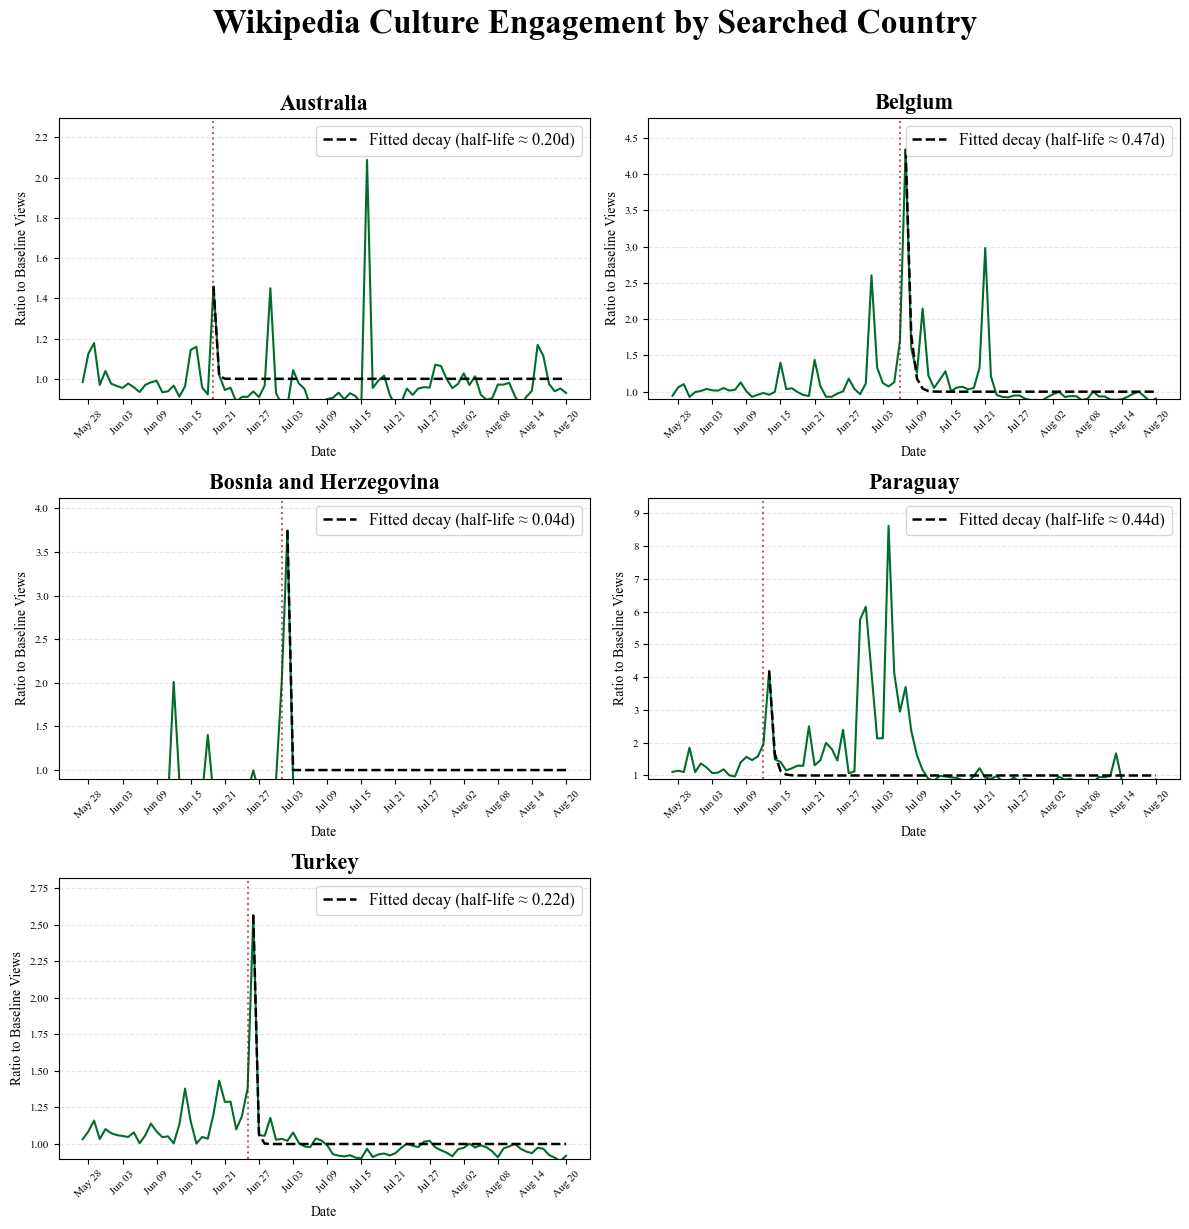

In [178]:
## I would define a function but I want to tune the parameters for each dataset individually

## This is the country decay curve

## Now plot timeseries with fitted decay

match_dates = {
    'Australia': pd.Timestamp('2026-06-19'),
    'Belgium': pd.Timestamp('2026-07-06'),
    'Bosnia_and_Herzegovina': pd.Timestamp('2026-07-01'),
    'Paraguay': pd.Timestamp('2026-06-12'),
    'Turkey': pd.Timestamp('2026-06-25'),
}

countries = list(match_dates.keys())

## Ensure date column is real datetime, once, up front
culture_final_plot_df['date'] = pd.to_datetime(culture_final_plot_df['date'])

fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=False, sharey=False)
axes = axes.flatten()

A = None

def decay_func(t, lam):
    return (A - 1) * np.exp(-lam * t) + 1

fit_results = []
    
for ax, country in zip(axes, countries):
    match_date = match_dates[country]
    
    test_d = culture_final_plot_df[culture_final_plot_df['country'] == country].sort_values('date').copy()
    ## Now define a window that tests if there is a nearby maximum from the match date

    
    ## Isolate data from the match date onward, for THIS country only
    post_match = test_d[test_d['date'] >= match_date].copy()
    post_match['days_since_match'] = (post_match['date'] - match_date).dt.days

    
    peak_window = post_match[(post_match['days_since_match'] >= 0) & (post_match['days_since_match'] <= 2)]

    if not peak_window.empty:
        peak_row = peak_window.loc[peak_window['ratio_to_baseline'].idxmax()]
        A = peak_row['ratio_to_baseline']
        peak_ratio_date = peak_row['days_since_match']
    else:
        A = post_match['ratio_to_baseline'].iloc[0]
        peak_ratio_date = 0
#& (post_match['days_since_match'] <= 30)].
    fitted_window = post_match[post_match['days_since_match'] >= peak_ratio_date].copy()
    fitted_window['t_since_peak'] = fitted_window['days_since_match'] - peak_ratio_date

    try:
        p0 = [0.2]
        params, pcov = curve_fit(decay_func, fitted_window['t_since_peak'], fitted_window['ratio_to_baseline'],
                              p0=p0, sigma=fitted_window['ratio_to_baseline'], maxfev=10000)
        lam_fit = params[0]
        fitted_curve = decay_func(fitted_window['t_since_peak'], lam_fit)
        half_life = np.log(2) / lam_fit

        se_lam = np.sqrt(np.diag(pcov))[0]
        se_half_life = se_lam * np.log(2) / (lam_fit ** 2)
        ss_res = np.sum((fitted_window['ratio_to_baseline'] - fitted_curve) ** 2)
        ss_tot = np.sum((fitted_window['ratio_to_baseline'] - fitted_window['ratio_to_baseline'].mean()) ** 2)
        r_squared = 1 - ss_res / ss_tot

        fit_label = f'Fitted decay (half-life ≈ {half_life:.2f}d)'
        fit_success = True

        fit_results.append({
        'country': country, 'peak_ratio': A, 'peak_day_since_match': peak_ratio_date,
        'lambda': lam_fit, 'lambda_se': se_lam,
        'half_life_days': half_life, 'half_life_se': se_half_life,
        'r_squared': r_squared, 'n_points_fit': len(fitted_window)
        })
    except Exception as e:
        print(f"Curve fit failed for {country}: {e}")
        fit_success = False
        fit_results.append({
        'country': country, 'peak_ratio': A, 'peak_day_since_match': peak_ratio_date,
        'lambda': np.nan, 'lambda_se': np.nan, 'half_life_days': np.nan,
        'half_life_se': np.nan, 'r_squared': np.nan, 'n_points_fit': len(fitted_window)
        })
    
    ## Plot raw data for THIS country only
    ax.plot(test_d['date'], test_d['ratio_to_baseline'], color='#006D2C', linewidth=1.5)
    
    if fit_success:
        ax.plot(fitted_window['date'], fitted_curve, color='#000000', linewidth=1.8,
                linestyle='--', label=fit_label)
        ax.legend(fontsize=12)
    
    ax.set_title(country.replace('_', ' '), fontsize=16, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=6))
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_xlabel("Date", fontsize=10)
    ax.set_ylabel("Ratio to Baseline Views", fontsize=10)
    ## y-axis scaled to THIS country's own max, not the global max
    ax.set_ylim(0.9, max(test_d['ratio_to_baseline']) * 1.1)
    
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.axvline(match_date, color='#8e0000', linestyle=':', alpha=0.6)

for i in range(5, len(axes)):
    fig.delaxes(axes[i])

fig.suptitle("Wikipedia Culture Engagement by Searched Country", fontsize=24, fontweight='bold', y=1.02)

plt.tight_layout()
fig.savefig('../outputs/figure_3.png', dpi=300, bbox_inches='tight')
plt.show()

In [161]:
pd.DataFrame(fit_results)

,country,peak_ratio,peak_day_since_match,lambda,lambda_se,half_life_days,half_life_se,r_squared,n_points_fit
0,Australia,1.459533,0,3.448746,8.189637e+00,0.200985,0.477274,0.095045,63
1,Belgium,4.343179,1,1.463516,2.874686e-01,0.473618,0.093030,0.651566,45
2,Bosnia_and_Herzegovina,3.749003,1,16.457937,1.228701e+06,0.042116,3144.277315,0.038181,50
3,Paraguay,4.192720,1,1.567648,7.399033e-01,0.442157,0.208691,-0.086765,69
4,Turkey,2.567355,1,3.168348,9.830575e-01,0.218772,0.067879,0.927904,56
